In [1]:
import pandas as pd

transport_df = pd.read_csv('data/transport_sample.csv',encoding='cp949')

weather_df = pd.read_csv('data/weather_2023.csv',encoding='cp949')

In [2]:
print(transport_df.head())
print(weather_df.head())

print(transport_df.info())
print(weather_df.info())

print(transport_df.describe())
print(weather_df.describe())

      기준_날짜    행정동_ID     승객_수  승객_수_00시  승객_수_01시  승객_수_02시  승객_수_03시  \
0  20241120  11250770  11134.0      69.0      25.0       2.0       3.0   
1  20241120  11250760   4164.0      13.0       2.0       0.0       0.0   
2  20241120  11250740  13198.0      25.0       0.0       1.0       2.0   
3  20241120  11250730   8424.0      85.0      19.0      31.0      12.0   
4  20241120  11250720   6558.0      36.0       8.0       5.0       4.0   

   승객_수_04시  승객_수_05시  승객_수_06시  ...  승객_수_14시  승객_수_15시  승객_수_16시  승객_수_17시  \
0      43.0     109.0     505.0  ...     509.0     735.0     660.0     776.0   
1      26.0      44.0     102.0  ...     291.0     311.0     374.0     452.0   
2      24.0     300.0     655.0  ...     620.0     645.0     715.0     881.0   
3      29.0     130.0     243.0  ...     355.0     520.0     563.0     611.0   
4      12.0      22.0     226.0  ...     342.0     459.0     452.0     426.0   

   승객_수_18시  승객_수_19시  승객_수_20시  승객_수_21시  승객_수_22시  승객_수_23시  
0    1090.

In [3]:
drop_columns = ['승객_수_' + str(i).zfill(2) + '시' for i in range(0, 24)]  
transport_df = transport_df.drop(drop_columns, axis=1)

In [4]:
print(transport_df.head())

      기준_날짜    행정동_ID     승객_수
0  20241120  11250770  11134.0
1  20241120  11250760   4164.0
2  20241120  11250740  13198.0
3  20241120  11250730   8424.0
4  20241120  11250720   6558.0


In [5]:
df = transport_df


df['기준_날짜'] = pd.to_datetime(df['기준_날짜'], format='%Y%m%d')


transport_df = df[(df['기준_날짜'] >= '2023-01-01') & (df['기준_날짜'] <= '2023-12-31')]



In [6]:
weather_df_fillna = weather_df.fillna(0)
weather_df=weather_df_fillna.drop(['기사'],axis=1)
weather_df

,지점,지점명,일시,평균기온(°C),일강수량(mm),평균 풍속(m/s),평균 증기압(hPa),합계 3시간 신적설(cm),평균 전운량(1/10)
0,108,서울,2023-01-01,-0.2,0.0,2.7,3.3,0.0,1.3
1,108,서울,2023-01-02,-4.5,0.0,2.5,2.0,0.0,0.0
2,108,서울,2023-01-03,-5.0,0.0,1.8,2.0,0.0,0.0
3,108,서울,2023-01-04,-1.8,0.0,1.9,2.7,0.0,1.9
4,108,서울,2023-01-05,-1.6,0.0,1.6,3.1,0.0,3.6
...,...,...,...,...,...,...,...,...,...
360,108,서울,2023-12-27,1.5,0.0,1.4,5.2,0.0,0.5
361,108,서울,2023-12-28,1.2,0.0,1.6,4.6,0.0,3.1
362,108,서울,2023-12-29,1.3,0.0,1.7,4.8,0.0,4.8
363,108,서울,2023-12-30,0.6,13.1,2.6,5.9,12.3,9.5


In [8]:
weather_df['일시'] = pd.to_datetime(weather_df['일시'], format='mixed')
transport_df['기준_날짜'] = pd.to_datetime(transport_df['기준_날짜'])
merged_data = pd.merge(transport_df, weather_df, left_on='기준_날짜', right_on='일시', how='left')


merged_data['승객_수'] = merged_data['승객_수'].fillna(0)
merged_data.drop('일시', axis=1, inplace=True)
print(merged_data.head())
merged_data.info()


       기준_날짜   행정동_ID     승객_수   지점 지점명  평균기온(°C)  일강수량(mm)  평균 풍속(m/s)  \
0 2023-12-31  1109069   7685.0  108  서울       2.1       4.7         2.0   
1 2023-12-31  1109065  14003.0  108  서울       2.1       4.7         2.0   
2 2023-12-31  1109062   5054.0  108  서울       2.1       4.7         2.0   
3 2023-12-31  1109061   6047.0  108  서울       2.1       4.7         2.0   
4 2023-12-31  1108085  18739.0  108  서울       2.1       4.7         2.0   

   평균 증기압(hPa)  합계 3시간 신적설(cm)  평균 전운량(1/10)  
0          6.8             0.0           5.8  
1          6.8             0.0           5.8  
2          6.8             0.0           5.8  
3          6.8             0.0           5.8  
4          6.8             0.0           5.8  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154064 entries, 0 to 154063
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   기준_날짜           154064 non-null  datetime64[n

/var/folders/6q/7y22nngn6y9fs7f1g_mzsydc0000gn/T/ipykernel_2605/211347727.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transport_df['기준_날짜'] = pd.to_datetime(transport_df['기준_날짜'])


In [9]:
from sklearn.model_selection import train_test_split

X = merged_data[['행정동_ID', '평균기온(°C)', '일강수량(mm)', '평균 풍속(m/s)', 
                '평균 증기압(hPa)', '합계 3시간 신적설(cm)', '평균 전운량(1/10)']]
y = merged_data['승객_수']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 결과 확인
print("학습 데이터 크기:", X_train.shape, y_train.shape)
print("테스트 데이터 크기:", X_test.shape, y_test.shape)

학습 데이터 크기: (123251, 7) (123251,)
테스트 데이터 크기: (30813, 7) (30813,)


In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score




X = merged_data[['행정동_ID', '평균기온(°C)', '일강수량(mm)', '평균 풍속(m/s)', 
                '평균 증기압(hPa)', '합계 3시간 신적설(cm)', '평균 전운량(1/10)']]
y = merged_data['승객_수']

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. 선형 회귀 모델
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

# 2. 의사결정 트리 모델
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

# 3. 랜덤 포레스트 모델
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# 모델 평가
def evaluate_model(y_true, y_pred, model_name):
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name} - RMSE: {rmse:.2f}, R-squared: {r2:.2f}")

evaluate_model(y_test, y_pred_linear, "선형 회귀")
evaluate_model(y_test, y_pred_tree, "의사결정 트리")
evaluate_model(y_test, y_pred_rf, "랜덤 포레스트")


선형 회귀 - RMSE: 24762.47, R-squared: 0.00
의사결정 트리 - RMSE: 11147.26, R-squared: 0.80
랜덤 포레스트 - RMSE: 8340.34, R-squared: 0.89


In [12]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [optuna]━━━━ 3/4 [optuna]
Note: you may need to restart the kernel to use updated packages.


In [15]:
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error

def objective(trial):
    # 하이퍼파라미터 탐색 공간
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 3, 10)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 4)

    # 모델 생성 및 학습
    rf_model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )
    rf_model.fit(X_train, y_train)

    # 예측 및 평가
    y_pred = rf_model.predict(X_test)
    rmse = root_mean_squared_error(y_test, y_pred)

    return rmse  # 최소화할 목표 함수

# Optuna study 생성
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # n_trials: 시도 횟수

# 최적 하이퍼파라미터
print("최적 하이퍼파라미터:", study.best_params)

# 최적 모델
best_rf_model = RandomForestRegressor(**study.best_params, random_state=42)
best_rf_model.fit(X_train, y_train)

# 예측 및 평가
y_pred_best = best_rf_model.predict(X_test)
rmse_best = root_mean_squared_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)
print(f"랜덤 포레스트 (튜닝 후) - RMSE: {rmse_best:.2f}, R-squared: {r2_best:.2f}")

[I 2026-05-27 22:04:51,590] A new study created in memory with name: no-name-dac67e9e-03f4-4737-bfbe-bc80e30f3042
[I 2026-05-27 22:04:59,773] Trial 0 finished with value: 21574.313683025855 and parameters: {'n_estimators': 166, 'max_depth': 4, 'min_samples_split': 8, 'min_samples_leaf': 3}. Best is trial 0 with value: 21574.313683025855.
[I 2026-05-27 22:05:13,217] Trial 1 finished with value: 14933.98516442946 and parameters: {'n_estimators': 121, 'max_depth': 9, 'min_samples_split': 2, 'min_samples_leaf': 1}. Best is trial 1 with value: 14933.98516442946.
[I 2026-05-27 22:05:18,392] Trial 2 finished with value: 18231.426971211382 and parameters: {'n_estimators': 61, 'max_depth': 7, 'min_samples_split': 9, 'min_samples_leaf': 4}. Best is trial 1 with value: 14933.98516442946.
[I 2026-05-27 22:05:28,960] Trial 3 finished with value: 20384.861511154693 and parameters: {'n_estimators': 174, 'max_depth': 5, 'min_samples_split': 9, 'min_samples_leaf': 2}. Best is trial 1 with value: 14933.

최적 하이퍼파라미터: {'n_estimators': 131, 'max_depth': 10, 'min_samples_split': 4, 'min_samples_leaf': 3}
랜덤 포레스트 (튜닝 후) - RMSE: 13620.02, R-squared: 0.70


In [16]:
import joblib

# 모델 저장
joblib.dump(best_rf_model, 'best_rf_model.pkl')

# 모델 로드
loaded_model = joblib.load('best_rf_model.pkl')


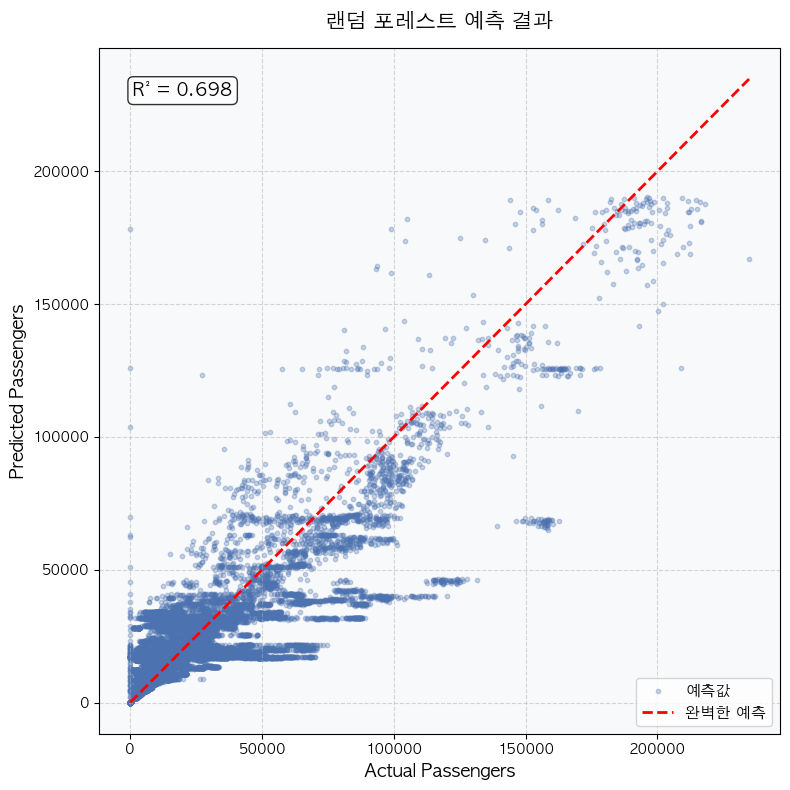

In [22]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 8))

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 배경 스타일
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#ffffff')

# 산점도
ax.scatter(y_test, y_pred_best, alpha=0.3, s=10, color='#4C72B0', label='예측값')

# 대각선 (완벽한 예측선)
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='완벽한 예측')

# R² 표시
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred_best)
ax.text(0.05, 0.95, f'R² = {r2:.3f}', transform=ax.transAxes,
        fontsize=13, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 레이블
ax.set_xlabel('Actual Passengers', fontsize=13)
ax.set_ylabel('Predicted Passengers', fontsize=13)
ax.set_title('랜덤 포레스트 예측 결과', fontsize=15, fontweight='bold', pad=15)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('prediction_result.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
import os
os.makedirs('data', exist_ok=True)

transport_df.sample(10000, random_state=42).to_csv('data/transport_sample.csv', index=False)
weather_df.to_csv('data/weather_2023.csv', index=False)